# Loan Status Prediction Using Machine Learning

## Project Overview

The objective of this project is to build and compare machine learning models that predict whether a loan application will be approved.

The project includes data cleaning, exploratory data analysis, categorical feature encoding, model training, and performance evaluation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


## Load the Dataset

In [4]:
# loading the dataset to pandas DataFrame
# Loading the dataset

loan_dataset = pd.read_csv("loan_data.csv")

In [5]:
print("Dataset Shape:", loan_dataset.shape)

loan_dataset.head()

Dataset Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Missing Values Analysis

In [7]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
missing_values = loan_dataset.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3


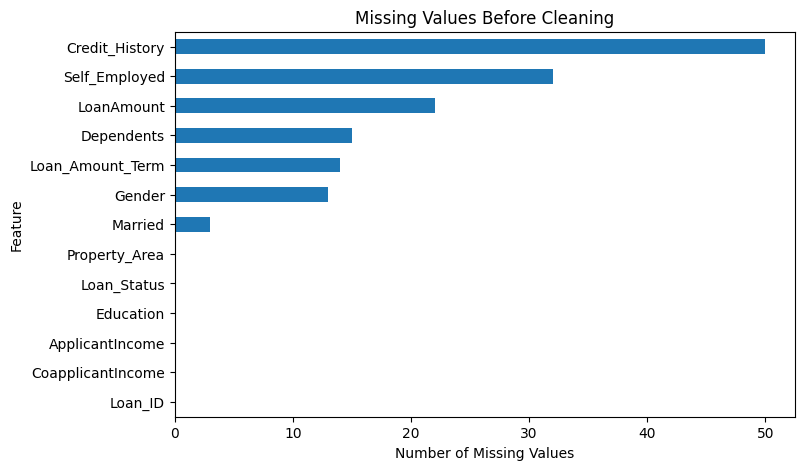

In [9]:
plt.figure(figsize=(8, 5))

missing_values.sort_values().plot(
    kind="barh"
)

plt.title("Missing Values Before Cleaning")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")
plt.show()

## Handling Missing Values

In [10]:
# Numerical columns
numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

# Categorical columns
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

In [11]:
# Fill numerical columns with the median

for column in numerical_columns:
    loan_dataset[column].fillna(
        loan_dataset[column].median(),
        inplace=True
    )

/tmp/ipykernel_1314/4284858193.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_dataset[column].fillna(


In [12]:
# Fill categorical columns with the most frequent value

for column in categorical_columns:
    loan_dataset[column].fillna(
        loan_dataset[column].mode()[0],
        inplace=True
    )

/tmp/ipykernel_1314/722638491.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_dataset[column].fillna(


In [13]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Exploratory Data Analysis

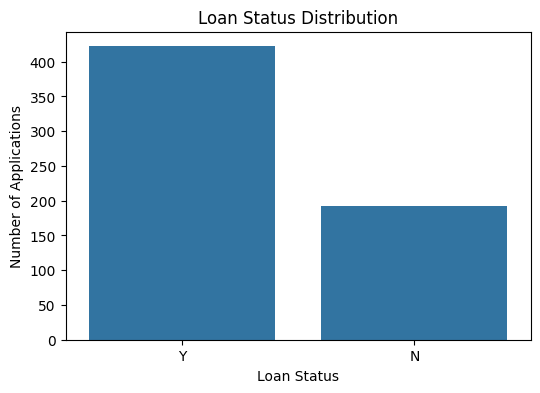

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=loan_dataset,
    x="Loan_Status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

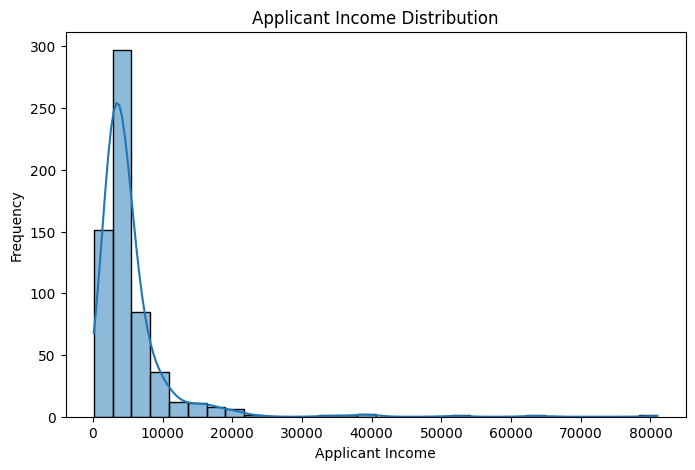

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=loan_dataset,
    x="ApplicantIncome",
    bins=30,
    kde=True
)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

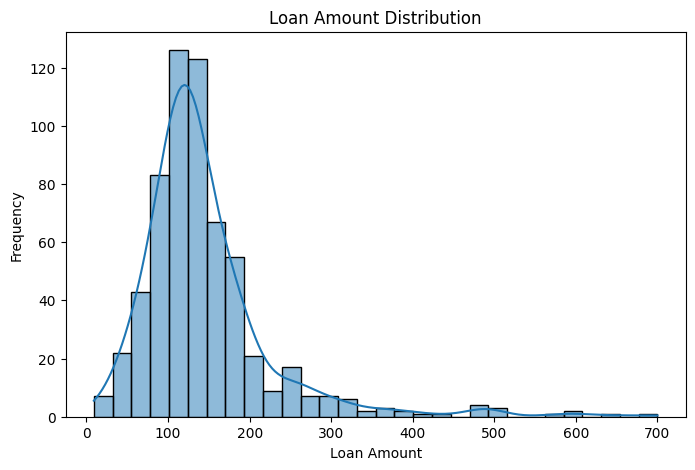

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=loan_dataset,
    x="LoanAmount",
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

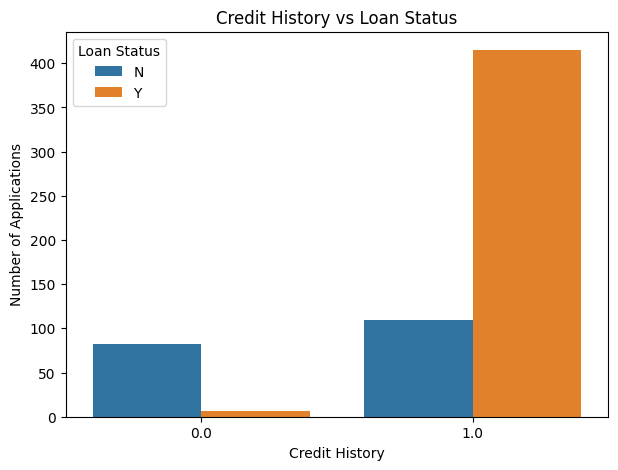

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=loan_dataset,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")
plt.legend(title="Loan Status")
plt.show()

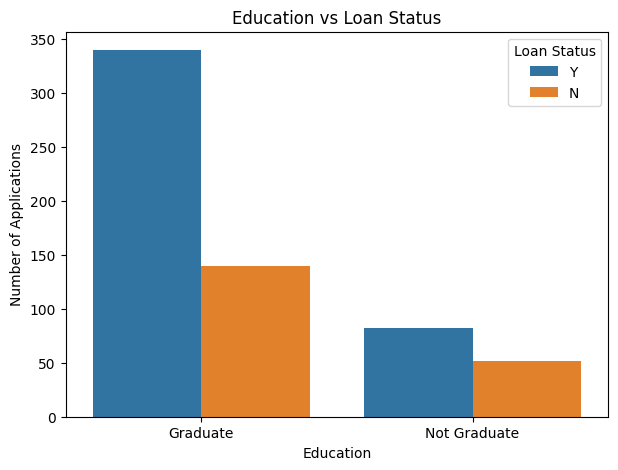

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=loan_dataset,
    x="Education",
    hue="Loan_Status"
)

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applications")
plt.legend(title="Loan Status")
plt.show()

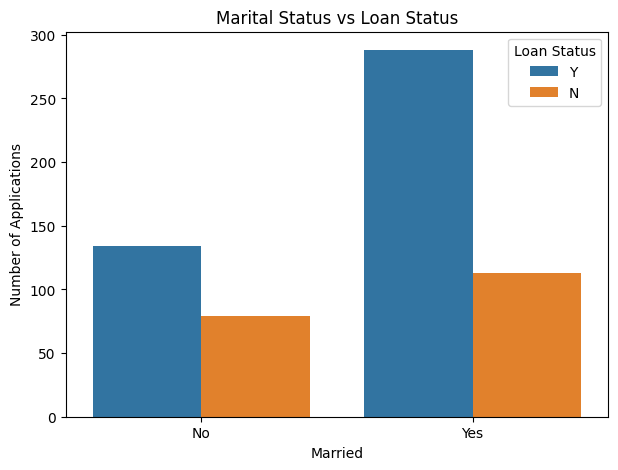

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=loan_dataset,
    x="Married",
    hue="Loan_Status"
)

plt.title("Marital Status vs Loan Status")
plt.xlabel("Married")
plt.ylabel("Number of Applications")
plt.legend(title="Loan Status")
plt.show()

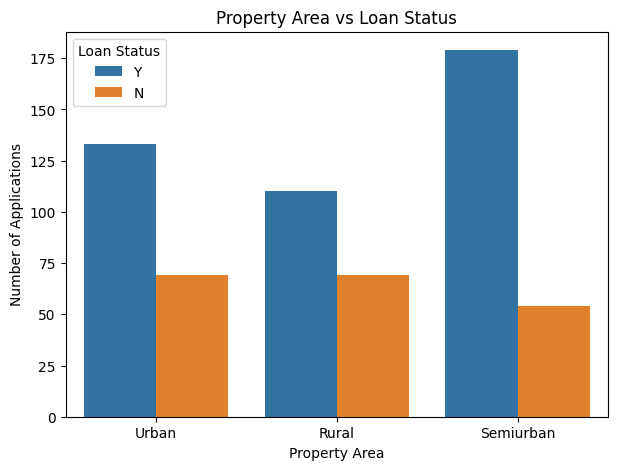

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=loan_dataset,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Property Area vs Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")
plt.legend(title="Loan Status")
plt.show()

In [21]:
model_data = loan_dataset.copy()

## Encoding Categorical Features

In [22]:
categorical_columns = model_data.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(loan_dataset[column].unique())


Loan_ID
['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP00128

In [23]:
model_data = model_data.drop(columns="Loan_ID")

In [24]:
model_data.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
model_data.replace(
    {
        "Loan_Status": {"N": 0, "Y": 1},
        "Gender": {"Male": 1, "Female": 0},
        "Married": {"Yes": 1, "No": 0},
        "Education": {"Graduate": 1, "Not Graduate": 0},
        "Self_Employed": {"Yes": 1, "No": 0},
        "Property_Area": {
            "Rural": 0,
            "Semiurban": 1,
            "Urban": 2,
        },
        "Dependents": {
            "0": 0,
            "1": 1,
            "2": 2,
            "3+": 3,
        },
    },
    inplace=True,
)

/tmp/ipykernel_1314/1512429135.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_data.replace(


In [26]:
model_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


## Correlation Analysis

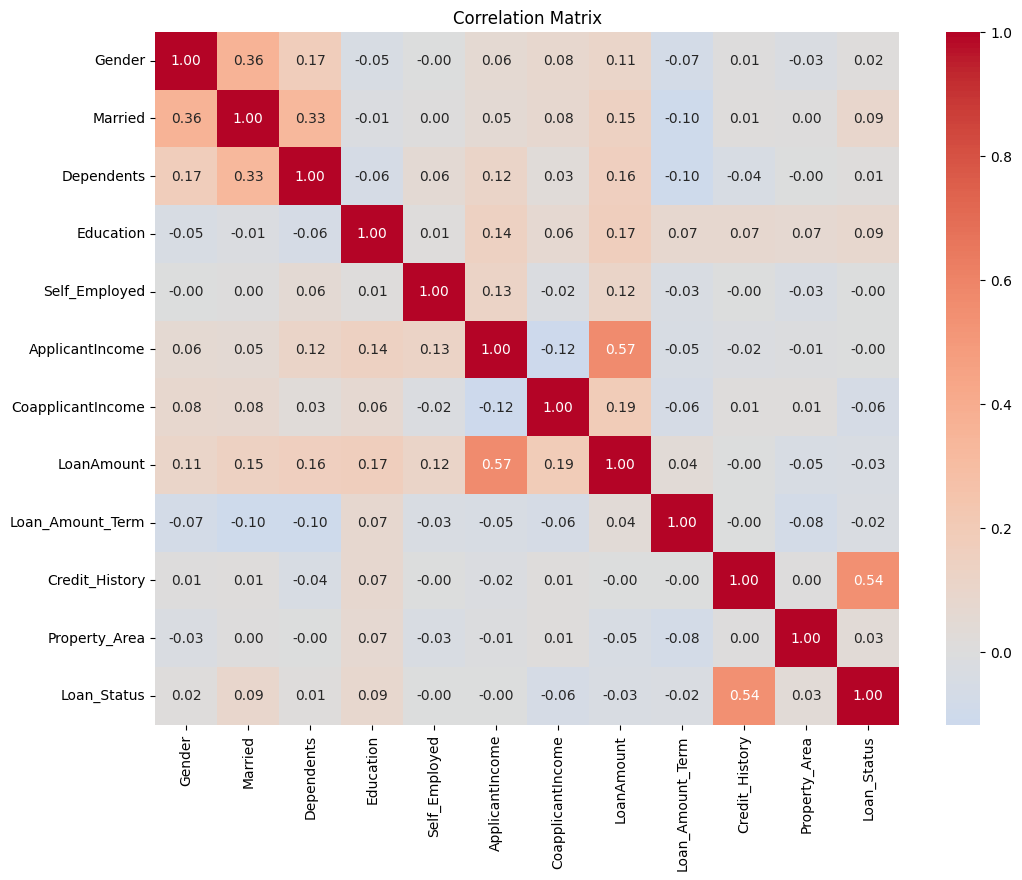

In [27]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    model_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Splitting the Data into Features and Target

In [28]:
# Features (Independent Variables)
X = model_data.drop(columns="Loan_Status")

# Target (Dependent Variable)
y = model_data["Loan_Status"]

In [29]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (614, 11)
Target Shape: (614,)


## Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Shape: (491, 11)
Testing Shape : (123, 11)

Training Class Distribution
Loan_Status
1    337
0    154
Name: count, dtype: int64

Testing Class Distribution
Loan_Status
1    85
0    38
Name: count, dtype: int64


## Feature Scaling

In [32]:
# Columns to scale
numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [33]:
X_train[numerical_features].head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
154,-0.352802,-0.563228,-1.131588,0.280691
239,-0.343346,-0.563228,-0.592309,0.280691
448,-0.339471,0.050405,0.040758,0.280691
471,-0.445963,-0.024953,-0.393010,-2.486768
273,-0.451078,0.234495,0.040758,0.280691


## Logistic Regression

In [34]:
log_model = LogisticRegression(random_state=42)

In [35]:
log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [36]:
log_predictions = log_model.predict(X_test)

In [37]:
log_accuracy = accuracy_score(
    y_test,
    log_predictions
)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

Logistic Regression Accuracy: 0.8618


In [38]:
log_cm = confusion_matrix(
    y_test,
    log_predictions
)

print(log_cm)

[[22 16]
 [ 1 84]]


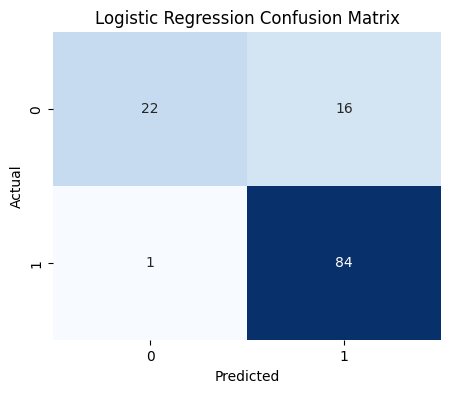

In [39]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    log_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
print(
    classification_report(
        y_test,
        log_predictions
    )
)

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [41]:
log_prob = log_model.predict_proba(X_test)[:, 1]

log_roc = roc_auc_score(
    y_test,
    log_prob
)

print(f"Logistic Regression ROC-AUC: {log_roc:.4f}")

Logistic Regression ROC-AUC: 0.7997


## Random Forest Classifier

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [43]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [44]:
rf_predictions = rf_model.predict(X_test)

In [45]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8374


In [46]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(rf_cm)

[[24 14]
 [ 6 79]]


In [47]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.80      0.63      0.71        38
           1       0.85      0.93      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.78      0.80       123
weighted avg       0.83      0.84      0.83       123



In [48]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_roc = roc_auc_score(
    y_test,
    rf_prob
)

print(f"Random Forest ROC-AUC: {rf_roc:.4f}")

Random Forest ROC-AUC: 0.7910


## Support Vector Machine

In [49]:
svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

In [50]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [51]:
svm_predictions = svm_model.predict(X_test)

In [52]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8537


In [53]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

print(svm_cm)

[[21 17]
 [ 1 84]]


In [54]:
print(
    classification_report(
        y_test,
        svm_predictions
    )
)

              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [55]:
svm_prob = svm_model.predict_proba(X_test)[:, 1]

svm_roc = roc_auc_score(
    y_test,
    svm_prob
)

print(f"SVM ROC-AUC: {svm_roc:.4f}")

SVM ROC-AUC: 0.7724


## Model Comparison

In [56]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        svm_accuracy
    ],
    "ROC-AUC": [
        log_roc,
        rf_roc,
        svm_roc
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results.reset_index(
    drop=True,
    inplace=True
)

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.861789,0.799690
1,Support Vector Machine,0.853659,0.772446
2,Random Forest,0.837398,0.791022


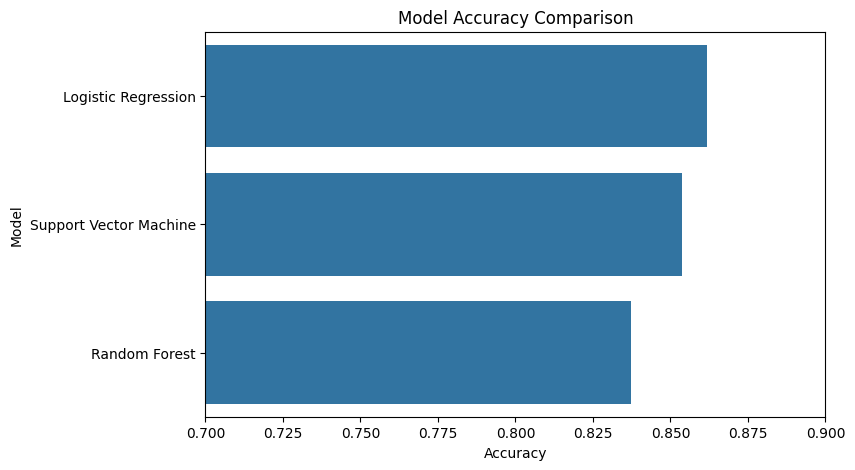

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.xlim(0.70, 0.90)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

## ROC Curve Comparison

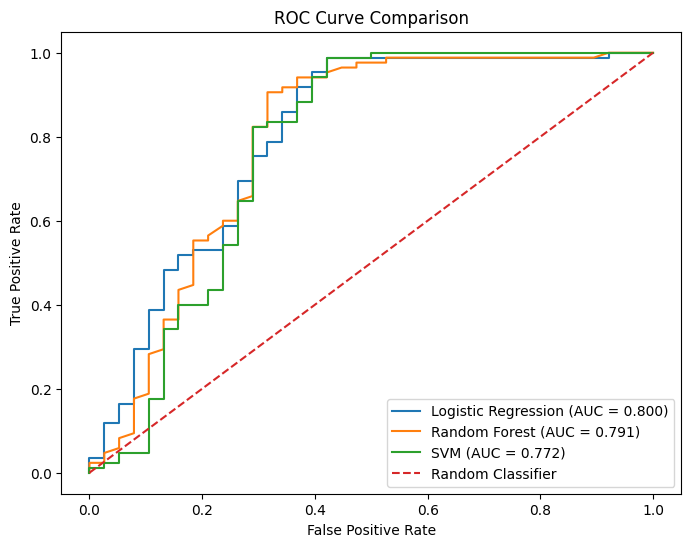

In [58]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_roc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc:.3f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {svm_roc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Random Forest Feature Importance

In [59]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Credit_History,0.239866
1,ApplicantIncome,0.210673
2,LoanAmount,0.192774
3,CoapplicantIncome,0.115698
4,Dependents,0.054873
5,Property_Area,0.048500
6,Loan_Amount_Term,0.047578
7,Married,0.027141
8,Education,0.026879
9,Gender,0.018248


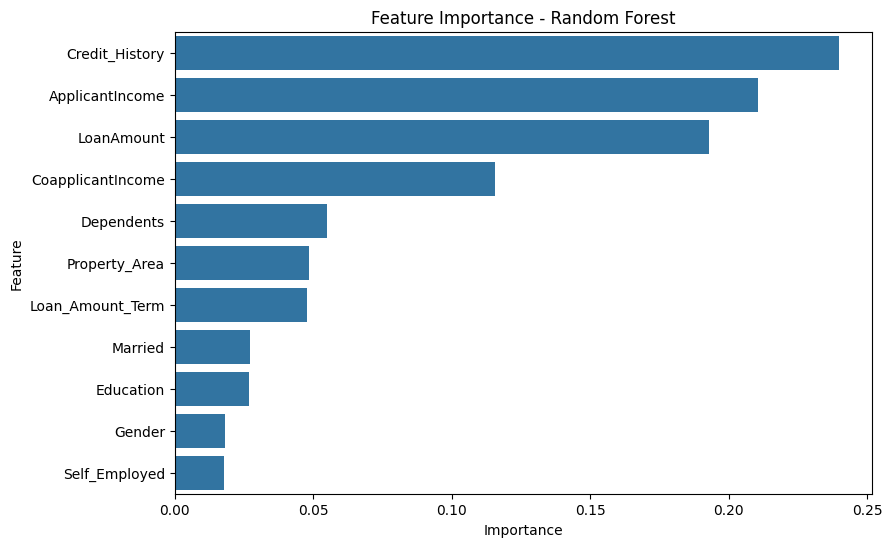

In [60]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Conclusion

Three classification models were evaluated for loan-status prediction:

- Logistic Regression
- Random Forest
- Support Vector Machine

Logistic Regression achieved the highest overall accuracy and ROC-AUC score on the test dataset.

Credit history was one of the strongest predictors of loan approval. The exploratory analysis also showed differences in approval patterns across education, marital status, and property area.

Future improvements may include:

- Hyperparameter tuning
- Cross-validation
- One-hot encoding for nominal categorical features
- Testing gradient-boosting models
- Building an interactive prediction application